__ANALYSIS OF $^{214}\text{Bi}$-MC FILES__

Pau has produced MC samples of $^{214}\text{Bi}$ decays in different volumes of the detector.
<br>
We are interested in:
- How many electrons coming from the $^{214}\text{Bi}$ @ cathode end up being fiducials.
- Energy specturm of fiducial electrons induced by $^{214}\text{Bi}$.
<!-- end of the list -->
This notebook has the following four main parts:
- In _Preliminary_ you define all the configuration needed for the use of this notebook.
- In _Analysis_, we apply $nS2 = 1$ cut and detector region tagging. Then, we define the input processed files for the _Spectrums_ (plotting purposes) and _ROI & Background Index_ analysis,
  <br>
  where we compute the important numbers such as rates, back. index, efficiencies.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import fit_functions as ff
from libs import plotting_tools as pt

from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import scipy
from typing import Tuple

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Preliminary

In [2]:
# ----- Date of Analysis ----- #
# DATE = datetime.now().strftime('%d%m%Y')        # Current Date
DATE = '17122025'                             # Specific Date

In [3]:
# ----------------------------------
# 1. INPUT FILES & EXTRA INFORMATION
# ----------------------------------
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/h5/'
ALL_FILENAME  = 'processed_MC_background_All_' + DATE + '.h5'
CATH_FILENAME = 'processed_MC_background_Cathode_' + DATE + '.h5'

# ----- MC Information ----- #
DETECTOR_ZONES = ['All', 'Cathode']
# All
RUN_TIME_ALL = 315360000                    # 10 years in [s]
# Cathode
RATE_SIM_CV = 0.82;  RATE_SIM_ERR = 0.04    # Simulated activity in [Hz]
scale_factor = 1.17 / RATE_SIM_CV           # If the actual simulated activity is different from original one (1.17 Hz)
RUN_TIME_CATH = 315360 * scale_factor       # 0.01 year in [s]

# Generated events | find these numbers in Bi_MC_Effs.txt
GEN_EVTS_ALL  = 2918945850
GEN_EVTS_CATH = 385000

# ----------------------
# 2. ANALYSIS PARAMETERS
# ----------------------
# ----- Trigger 2 Efficiency Cut ----- #
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5    # in [MeV]

# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# ---- ROI definition ----
ROI_MIN = 2.4; ROI_MAX = 2.5    # in [MeV]

#### Dictionary of interest

In [4]:
# Bi statistics
Bi_MC_INFO = {
                'All': {
                                'gen_cv': GEN_EVTS_ALL,
                                'incl_cv': 0.0,         'incl_err': 0.0,
                                'incl_roi_cv': 0.0,
                                'fidu_cv': 0.0,         'fidu_err': 0.0,
                                'fidu_roi_cv': 0.0
                        },

                'Cathode': {
                                'gen_cv': GEN_EVTS_CATH,
                                'incl_cv': 0.0,         'incl_err': 0.0,
                                'incl_roi_cv': 0.0,
                                'fidu_cv': 0.0,         'fidu_err': 0.0,
                                'fidu_roi_cv': 0.0
                        }
}

# ROI information
ROI_INFO = {    
                'inclusive':{
                                'dataframe': pd.DataFrame(),
                                'rate_cv': 0,  'rate_err': 0
                },

                'fiducial': {
                                'dataframe': pd.DataFrame(),
                                'rate_cv': 0,  'rate_err': 0
                }
}

Here you have your processed dataframes!

In [5]:
ALL_MC_EVT_DF = pd.read_hdf(os.path.join(INPUT_DIR, ALL_FILENAME), key='Events')
ALL_MC_EVT_DF

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_mev,n_cluster,nS1,nS2,S1e,S1e_corr,isotope,volume,global_event,region
0,0,1.253990e+06,-344.062292,-165.221148,33.491546,15.618709,44.207833,438.390558,0.402713,1,1,2,154.0,301.240324,Bi214,ANODE_RING,0,anode
1,1,2.387403e+06,-126.622985,-96.187692,786.343249,20.197641,1122.937601,421.680941,0.439779,2,1,3,214.0,416.544628,Bi214,ANODE_RING,1,anode
2,2,4.019228e+06,-289.211259,-104.123245,94.026652,45.461306,172.613587,384.056033,1.228004,0,1,1,404.0,760.200979,Bi214,ANODE_RING,2,fiducial
3,4,8.671749e+06,54.690894,303.960486,224.723701,144.440472,270.774260,373.793521,0.611557,1,1,2,224.0,394.683128,Bi214,ANODE_RING,3,fiducial
4,6,1.259170e+07,-44.761349,-97.411481,258.288332,206.304826,307.595215,356.693883,0.567312,2,1,2,219.0,360.642406,Bi214,ANODE_RING,4,fiducial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938276,1079049162,2.158098e+15,10.500844,-77.494315,1068.066358,1027.056315,1092.366998,468.466361,0.606246,0,1,1,343.0,361.228568,Bi214,VESSEL,938276,tube
938277,1079049163,2.158098e+15,354.418014,225.414714,1163.723800,1138.192943,1196.814195,501.140880,0.862196,0,1,1,366.0,372.285740,Bi214,VESSEL,938277,cathode
938278,1079049164,2.158098e+15,-56.628661,-334.027075,143.636026,122.202824,159.503190,410.315106,0.690275,0,1,1,237.0,420.271670,Bi214,VESSEL,938278,fiducial
938279,1079049165,2.158098e+15,-60.273219,183.985071,208.540667,116.515335,345.904306,413.841831,0.905250,1,1,2,339.0,565.987428,Bi214,VESSEL,938279,fiducial


In [6]:
CATHODE_MC_EVT_DF = pd.read_hdf(os.path.join(INPUT_DIR, CATH_FILENAME), key='Events')
CATHODE_MC_EVT_DF

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_mev,n_cluster,nS1,nS2,S1e,S1e_corr,isotope,volume,global_event,region
0,0,1.434202e+06,169.343029,4.040181,1048.267768,660.045456,1275.048836,511.922832,1.056133,3,1,4,343.0,437.000344,Bi214,CATHODE_SURF,0,cathode
1,1,2.309077e+06,-311.193402,256.576148,1151.741938,1133.088217,1188.223489,528.117758,0.488223,0,1,2,246.0,250.688353,Bi214,CATHODE_SURF,1,cathode
2,4,9.143824e+06,-389.348785,-251.846303,1220.717102,1156.417702,1294.694959,539.255604,0.936507,1,1,2,279.0,280.393556,Bi214,CATHODE_SURF,2,cathode
3,5,1.199260e+07,-427.131233,139.167993,1177.332623,1164.223125,1195.189253,506.334036,0.356754,0,1,2,162.0,163.164429,Bi214,CATHODE_SURF,3,cathode
4,6,1.368604e+07,-273.631751,-316.367478,1064.283783,1052.100026,1075.893765,473.768858,0.247048,0,1,2,128.0,135.265437,Bi214,CATHODE_SURF,4,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275788,384974,7.699485e+11,210.045642,-162.657607,1182.972533,1170.394687,1197.573052,317.859483,0.279856,0,1,1,133.0,133.714388,Bi214,CATHODE_SURF,275788,cathode
275789,384975,7.699515e+11,157.697665,402.047164,1222.142934,1138.291361,1245.364436,578.582441,8.192628,1,1,1,277.0,273.325574,Bi214,CATHODE_SURF,275789,cathode
275790,384976,7.699524e+11,-283.033723,281.355039,1173.478481,1026.862305,1214.045198,572.328604,9.830983,1,1,2,846.0,846.540262,Bi214,CATHODE_SURF,275790,cathode
275791,384977,7.699542e+11,-240.705070,-377.714782,1183.229019,1169.617342,1193.452732,487.944276,0.167344,0,1,2,63.0,63.245754,Bi214,CATHODE_SURF,275791,cathode


# Trigger02 Cut: or inclusive sample

In [7]:
# List for updated dataframes
updated_dfs = []

for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):
    
    trg2_mask = (dataframe['E_mev'] >= TRG2_THRESHOLD)
    events_after_trg2_ids = dataframe.loc[trg2_mask, 'global_event'].unique()
    incl_evts = len(events_after_trg2_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['incl_cv'] = incl_evts
    print(f"{label} MC [Energy ≥ {TRG2_THRESHOLD} MeV]: {incl_evts} events ({incl_evts/dataframe['global_event'].nunique():.2%})")

    # Update dataframe
    new_df = dataframe[dataframe['global_event'].isin(events_after_trg2_ids)].copy()
    updated_dfs.append(new_df)

ALL_MC_EVT_DF, CATHODE_MC_EVT_DF = updated_dfs

All MC [Energy ≥ 0.5 MeV]: 672414 events (71.66%)
Cathode MC [Energy ≥ 0.5 MeV]: 178023 events (64.55%)


Extract ROI information

In [8]:
for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):
    
    roi_mask = (dataframe['E_mev'] >= ROI_MIN) & (dataframe['E_mev'] <= ROI_MAX)
    events_roi_ids = dataframe.loc[roi_mask, 'global_event'].unique()
    incl_evts_in_roi = len(events_roi_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['incl_roi_cv'] = incl_evts_in_roi
    print(f"{label} MC: {incl_evts_in_roi} inclusive events in ROI")

All MC: 250 inclusive events in ROI
Cathode MC: 398 inclusive events in ROI


# Fiducial Electrons

In [9]:
# New fiducial dataframes
FIDU_ALL_MC_EVT_DF     = pd.DataFrame()
FIDU_CATHODE_MC_EVT_DF = pd.DataFrame()
updated_dfs = []

for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):

    # 1 S2 & fiducial region
    fid_mask = (dataframe['nS2'] == 1) & (dataframe['region'] == 'fiducial')
    events_fid_ids = dataframe.loc[fid_mask, 'global_event'].unique()
    fid_evts = len(events_fid_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['fidu_cv'] = fid_evts
    print(f"{label} MC - Fiducial: {fid_evts} events ({fid_evts/dataframe['global_event'].nunique():.2%})")

    # Update dataframe
    new_df = dataframe[dataframe['global_event'].isin(events_fid_ids)].copy()
    updated_dfs.append(new_df)

FIDU_ALL_MC_EVT_DF, FIDU_CATHODE_MC_EVT_DF = updated_dfs

All MC - Fiducial: 162683 events (24.19%)
Cathode MC - Fiducial: 98 events (0.06%)


Extract ROI information

In [10]:
for i, dataframe in enumerate([FIDU_ALL_MC_EVT_DF, FIDU_CATHODE_MC_EVT_DF]):
    
    roi_mask = (dataframe['E_mev'] >= ROI_MIN) & (dataframe['E_mev'] <= ROI_MAX)
    events_roi_ids = dataframe.loc[roi_mask, 'global_event'].unique()
    fidu_evts_in_roi = len(events_roi_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['fidu_roi_cv'] = fidu_evts_in_roi
    print(f"{label} MC: {fidu_evts_in_roi} fiducial events in ROI")

All MC: 23 fiducial events in ROI
Cathode MC: 0 fiducial events in ROI


### Complete Bi-MC Information

In [11]:
Bi_MC_INFO

{'All': {'gen_cv': 2918945850,
  'incl_cv': 672414,
  'incl_err': 0.0,
  'incl_roi_cv': 250,
  'fidu_cv': 162683,
  'fidu_err': 0.0,
  'fidu_roi_cv': 23},
 'Cathode': {'gen_cv': 385000,
  'incl_cv': 178023,
  'incl_err': 0.0,
  'incl_roi_cv': 398,
  'fidu_cv': 98,
  'fidu_err': 0.0,
  'fidu_roi_cv': 0}}

In [12]:
# Efficiency of recontruction (inclusive events) comes from Bi-MC @ cathode
Eff_Reco = Bi_MC_INFO['Cathode']['incl_cv'] / Bi_MC_INFO['Cathode']['gen_cv']

for mc in DETECTOR_ZONES:
    
    # Inclusive events
    eff_incl = Bi_MC_INFO[mc]['incl_cv'] / Bi_MC_INFO[mc]['gen_cv']
    incl_evts, incl_var = scipy.stats.binom.stats(n=Bi_MC_INFO[mc]['gen_cv'], p=eff_incl, moments='mv')
    print(f"{mc} MC - Inclusive:")
    print(f"  {incl_evts:.2f} ± {np.sqrt(incl_var):.2f} events")
    Bi_MC_INFO[mc]['incl_err'] = np.sqrt(incl_var)

    # Fiducial events
    eff_fidu = Bi_MC_INFO[mc]['fidu_cv'] / Bi_MC_INFO[mc]['gen_cv']
    fidu_evts, fidu_var = scipy.stats.binom.stats(n=Bi_MC_INFO[mc]['gen_cv'], p=eff_fidu, moments='mv')
    print(f"{mc} MC - Fiducial:")
    print(f"  {fidu_evts:.2f} ± {np.sqrt(fidu_var):.2f} events\n")
    Bi_MC_INFO[mc]['fidu_err'] = np.sqrt(fidu_var)

    # print('OR')

    # test_evts, test_var = scipy.stats.binom.stats(n=Bi_MC_INFO[mc]['gen_cv'], p=Bi_MC_INFO[mc]['incl_cv']/Bi_MC_INFO[mc]['gen_cv'], moments='mv')
    # print(f"{mc} MC - Inclusive Events Reconstruction Efficiency:")
    # print(f"  - CV: {test_evts:.0f}")
    # print(f"  - 1σ Error: {np.sqrt(test_var):.0f}\n")


All MC - Inclusive:
  672414.00 ± 819.91 events
All MC - Fiducial:
  162683.00 ± 403.33 events

Cathode MC - Inclusive:
  178023.00 ± 309.36 events
Cathode MC - Fiducial:
  98.00 ± 9.90 events



# Spectrums

Let's check if our dataframes are what we believe they are

### $Z$ Distribution

Acomodar bien!

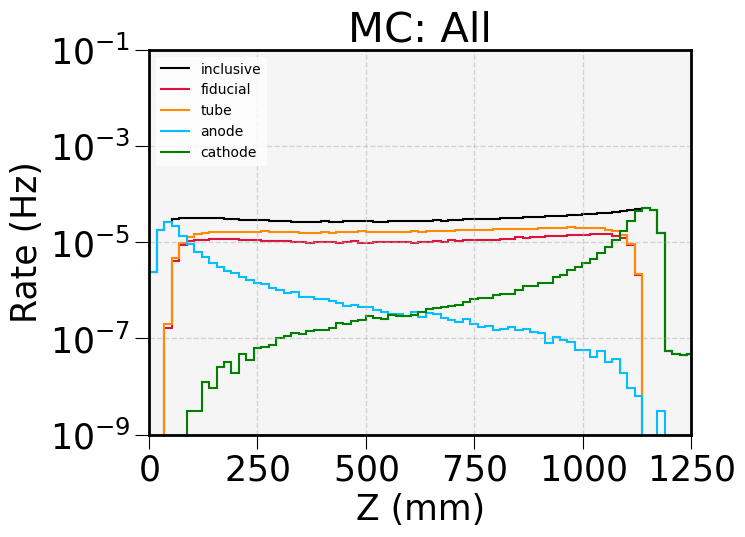

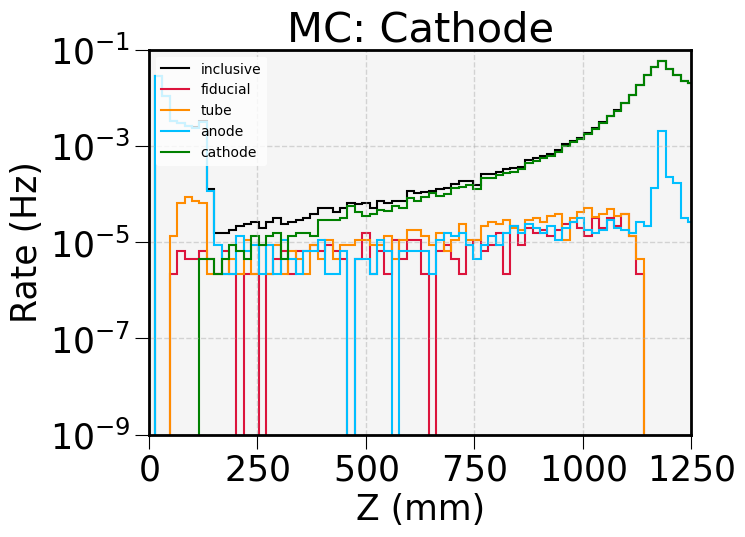

In [12]:
# Global
n_bins = 75
regions  = ['inclusive', 'fiducial', 'tube', 'anode', 'cathode']

for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):

    plt.figure(figsize=(7, 5))
    plt.title(f'MC: {DETECTOR_ZONES[i]}')

    # Binning using "Inclusive" region
    _, Z_edges = np.histogram(dataframe['Z_bary'], bins=n_bins)

    for j, region in enumerate(regions):

        # Dataframe
        if region == 'inclusive':
            mc_region = dataframe.copy()
        else:
            mc_region = dataframe[dataframe['region'] == region].copy()

        # Variables
        Z = mc_region['Z_bary']

        # Histogram
        Z_counts, _ = np.histogram(Z, bins=Z_edges)
        Z_rate = Z_counts / (RUN_TIME_ALL if DETECTOR_ZONES[i] == 'All' else RUN_TIME_CATH)

        # ----- Plotting ----- #
        plt.stairs(Z_rate, Z_edges, label=region, 
                   fill=False, lw=1.5, ec=pt.hist_colors[j % len(pt.hist_colors)])
 
    # ----- Styling ----- #
    plt.xlabel('Z (mm)')
    plt.xlim(0, 1250)
    plt.ylabel('Rate (Hz)')
    plt.yscale('log')
    plt.ylim(1e-9, 1e-1)
    plt.legend(loc='upper left', fontsize=10)
    plt.title(f'MC: {DETECTOR_ZONES[i]}')
    plt.grid(True)
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### $E$ Distribution
First, let's see the energy distribution for $^{214}Bi$-MC @ cathode

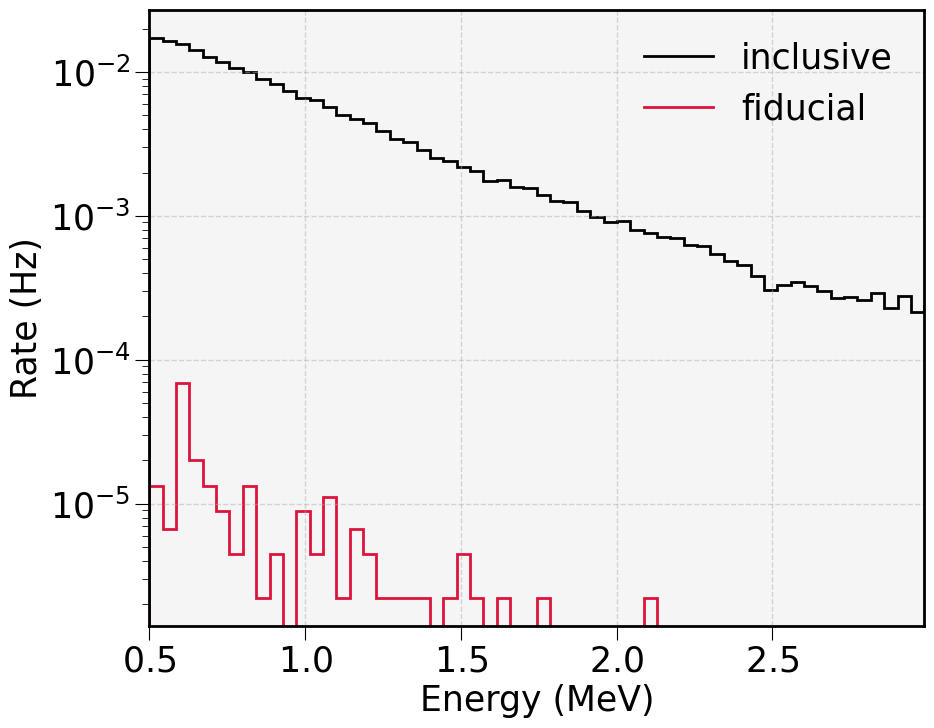

In [13]:
# Global
n_bins = 250
fig, ax = plt.subplots()

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, E_edges = np.histogram(CATHODE_MC_EVT_DF['E_mev'], bins=n_bins)

for i, region in enumerate(['inclusive', 'fiducial']):

    # Dataframe
    if region == 'inclusive':  mc_df = CATHODE_MC_EVT_DF.copy()
    else:                      mc_df = FIDU_CATHODE_MC_EVT_DF.copy()

    # Variables
    E = mc_df['E_mev']

    # Histogram
    E_counts, _ = np.histogram(E, bins=E_edges)
    E_rate = E_counts / RUN_TIME_CATH

    # ----- Plotting ----- #
    plt.stairs(E_rate, E_edges, label=region, 
               fill=False, ec=pt.hist_colors[i % len(pt.hist_colors)], lw=2.0)
    
# plt.axvline(x=1.59, c='grey', ls='--', lw=1.0)        # DEP
    
# # ----- Styling ----- #
# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (2.8, 6e-3)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (MeV)')
plt.xlim(TRG2_THRESHOLD, min(E_edges, key=lambda x: abs(x - 3)))
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.legend(framealpha=0)
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Bi_Energy_Spectrum_Cathode_MC.pdf')
plt.show()

#### __Now _All-MC_, but normalized to cathode rates__

At the same time, we obtain the rate (from cathode MC) and the events (from all MC) in the ROI??? or maybe just ROI Rate re-escalated

In [24]:
Bi_MC_INFO

{'All': {'gen_cv': 2918945850,
  'incl_cv': 672414,
  'incl_err': 819.9140817263125,
  'incl_roi_cv': 250,
  'fidu_cv': 162683,
  'fidu_err': 403.32856718913297,
  'fidu_roi_cv': 23},
 'Cathode': {'gen_cv': 385000,
  'incl_cv': 178023,
  'incl_err': 309.363260904398,
  'incl_roi_cv': 398,
  'fidu_cv': 98,
  'fidu_err': 9.898234920704526,
  'fidu_roi_cv': 0}}


--- Processing Region: INCLUSIVE ---

MC Background = 672414.00 ± 820.01 events
Scale factor from Cathode-MC = 0.264752 ± 0.029123
Scaled MC = 178023.00 ± 217.10 events
Scaled rate = 395.6375 ± 0.4825 mHz

ROI [2.4, 2.5] MeV Analysis for INCLUSIVE:

  Unscaled events in ROI from dataframe = 250.00 ± 15.81 events
  Scaled events in ROI from dataframe = 66.1880 ± 4.1861 events
  Rate in ROI from dataframe = (1.47e-01 ± 9.30e-03) mHz

--- Processing Region: FIDUCIAL ---

MC Background = 162683.00 ± 403.34 events
Scale factor from Cathode-MC = 0.000602 ± 0.000066
Scaled MC = 98.00 ± 0.24 events
Scaled rate = 0.2178 ± 0.0005 mHz

ROI [2.4, 2.5] MeV Analysis for FIDUCIAL:

  Unscaled events in ROI from dataframe = 23.00 ± 4.80 events
  Scaled events in ROI from dataframe = 0.0139 ± 0.0029 events
  Rate in ROI from dataframe = (3.08e-05 ± 6.42e-06) mHz

--- Processing Region: FIDUCIAL (BIPO) ---

MC Background = 98.00 ± 9.90 events
Scale factor from Cathode-MC = 1.000000 ± 0.110000
Scaled MC

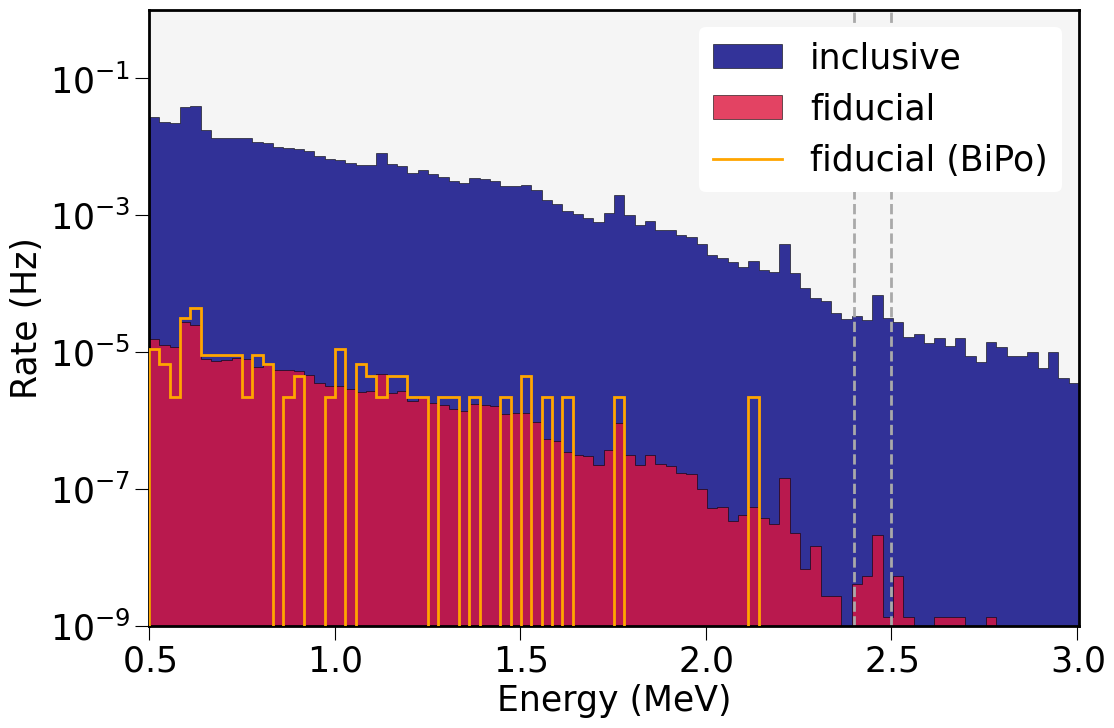

In [44]:
# Global
n_bins = 250
color_plot = ['navy', 'crimson']
fig, ax = plt.subplots(figsize=(12, 8))

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, E_edges = np.histogram(ALL_MC_EVT_DF['E_mev'], bins=n_bins)

for i, region in enumerate(['inclusive', 'fiducial', 'fiducial (BiPo)']):

    print(f"\n--- Processing Region: {region.upper()} ---")

    # Dataframe and cathode MC information
    if region == 'inclusive':
        mc_df = ALL_MC_EVT_DF.copy()
        evt_all_cv  = Bi_MC_INFO['All']['incl_cv'];      evt_cathode_cv  = Bi_MC_INFO['Cathode']['incl_cv']
        evt_all_err = Bi_MC_INFO['All']['incl_err'];     evt_cathode_err = Bi_MC_INFO['Cathode']['incl_err']
    elif region == 'fiducial':
        mc_df = FIDU_ALL_MC_EVT_DF.copy()
        evt_all_cv  = Bi_MC_INFO['All']['fidu_cv'];      evt_cathode_cv  = Bi_MC_INFO['Cathode']['fidu_cv']
        evt_all_err = Bi_MC_INFO['All']['fidu_err'];     evt_cathode_err = Bi_MC_INFO['Cathode']['fidu_err']
    else:
        mc_df = FIDU_CATHODE_MC_EVT_DF.copy()
        evt_all_cv  = 1.0;     evt_cathode_cv = 1.0      # There is no scaling in this case
        evt_all_err = 0.0;     evt_cathode_err = 0.0

    # Variables
    E = mc_df['E_mev']

    # ----- Normalize Histogram (by Cathode MC) ----- #
    E_counts, _  = np.histogram(E, bins=E_edges)
    E_counts_err = np.sqrt(E_counts)                # Poisson errors (in bin)
    print(f"\nMC Background = {E_counts.sum():.2f} ± {np.sqrt(np.sum(E_counts_err**2)):.2f} events")
    # Computing the scale factor
    scale_factor_cv  = evt_cathode_cv / evt_all_cv
    scale_factor_err = scale_factor_cv * 0.11       # 11% systematic error from Bi estimation @ cathode!
    print(f"Scale factor from Cathode-MC = {scale_factor_cv:.6f} ± {scale_factor_err:.6f}")
    # Scaling the counts
    E_counts_scaled_cv  = E_counts * scale_factor_cv
    E_counts_scaled_err = E_counts_err * scale_factor_cv     # Only statistical errors
    print(f"Scaled MC = {E_counts_scaled_cv.sum():.2f} ± {np.sqrt(np.sum(E_counts_scaled_err**2)):.2f} events")
    # Computing the rate + error
    E_rate_cv  = E_counts_scaled_cv / RUN_TIME_CATH                                    # Important to use the MC time exposure of cathode sample
    E_rate_err = E_counts_scaled_err / RUN_TIME_CATH
    print(f"Scaled rate = {E_rate_cv.sum()*1e3:.4f} ± {np.sqrt(np.sum(E_rate_err**2))*1e3:.4f} mHz")

    # ----- Extract ROI Rate from Normalized Histograms ----- #
    roi_df = pd.DataFrame()
    if region in ['inclusive', 'fiducial']:
        print(f"\nROI [{ROI_MIN}, {ROI_MAX}] MeV Analysis for {region.upper()}:\n")

        # ROI dataframe
        roi_df = mc_df[mc_df['E_mev'].between(ROI_MIN, ROI_MAX)].copy()    # Inclusive bounds
        ROI_INFO[region]['dataframe'] = roi_df

        # ----- Dataframe Method ----- #
        # Scaling events
        unscaled_evts_in_roi_cv  = roi_df['global_event'].nunique()
        unscaled_evts_in_roi_err = np.sqrt(unscaled_evts_in_roi_cv)         # Poisson error
        print(f"  Unscaled events in ROI from dataframe = {unscaled_evts_in_roi_cv:.2f} ± {unscaled_evts_in_roi_err:.2f} events")
        scaled_evts_in_roi_cv  = unscaled_evts_in_roi_cv * scale_factor_cv
        scaled_evts_in_roi_err = unscaled_evts_in_roi_err * scale_factor_cv
        print(f"  Scaled events in ROI from dataframe = {scaled_evts_in_roi_cv:.4f} ± {scaled_evts_in_roi_err:.4f} events")

        # Compute ROI rate and error from dataframe
        roi_rate_df_cv  = scaled_evts_in_roi_cv / RUN_TIME_CATH
        roi_rate_df_err = scaled_evts_in_roi_err / RUN_TIME_CATH
        print(f"  Rate in ROI from dataframe = ({roi_rate_df_cv*1e3:.2e} ± {roi_rate_df_err*1e3:.2e}) mHz")
        ROI_INFO[region]['rate_cv']  = roi_rate_df_cv
        ROI_INFO[region]['rate_err'] = roi_rate_df_err

        # # ----- Histogram Method ----- #
        # # Mask for bin centers in ROI
        # bin_centers  = (E_edges[:-1] + E_edges[1:]) / 2
        # roi_bin_mask = (bin_centers >= ROI_MIN) & (bin_centers <= ROI_MAX)

        # # Compute ROI rate and error from histogram
        # roi_rate_cv  = np.sum(E_rate_cv[roi_bin_mask])
        # roi_rate_err = np.sqrt(np.sum(E_rate_err[roi_bin_mask]**2))
        # print(f"Rate in ROI from histogram = ({roi_rate_cv*1e3:.2e} ± {roi_rate_err*1e3:.2e}) mHz")
        # ROI_INFO[region]['rate_cv']  = roi_rate_cv
        # ROI_INFO[region]['rate_err'] = roi_rate_err

    # ----- Plotting ----- #
    if region in ['inclusive', 'fiducial']:
        plt.stairs(E_rate_cv, E_edges, label=region, 
                   fill=True, color=color_plot[i], alpha=0.8,
                   ec='black', lw=0.5, zorder=i+1)
    else: # 'fiducial (BiPo)'
        plt.stairs(E_rate_cv, E_edges, label=region, 
                  fill=False, ec='orange', lw=2.0, ls='-', zorder=i+1)
        
# # Important lines
# for x_peaks in [0.609, 1.120, 1.377, 1.764, 2.204, 2.447, 2.4, 2.5]:
#     plt.axvline(x=x_peaks, c='grey', ls='--', lw=1.0)

plt.axvline(x=ROI_MIN, c='darkgray', ls='--')        # ROI min
plt.axvline(x=ROI_MAX, c='darkgray', ls='--')        # ROI max
    
# # ----- Styling ----- #
# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (2.35, 3e-3)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (MeV)')
plt.xlim(TRG2_THRESHOLD, min(E_edges, key=lambda x: abs(x - 3)))
plt.ylabel('Rate (Hz)')
plt.ylim(1e-9, 1e0)
plt.yscale('log')
plt.legend(loc='upper right', framealpha=1.0)

plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Bi_Energy_Spectrum.pdf')
plt.show()

# Rejection Factors & Background Indices

#### Helper functions & detector values

In [45]:
# ----- Fiducial Mass ----- #
volume_fid_CV, _ = pt.selection_volume(Z_UP - Z_LOW, 1, R_UP, 1)            # in mm3 - DO NOT USE THIS ERROR
volume_fid_CV /= 1e9                                                        # in m3
temp     = 293.15       # in [K]
pressure = 3.95         # in [bar]
R_gas    = 8.3145e-5    # in [m3·bar/(K·mol)]

# Use PV = nRT to calculate the number of moles
n_moles = (pressure * volume_fid_CV) / (R_gas * temp)    # in mol
print(f"Fiducial: number of moles = {n_moles:.4f} mol")
# Xenon molar mass
molar_mass_Xe = 135.9072    # in [g/mol]
MASS_FID_CV = n_moles * molar_mass_Xe / 1e3    # in [kg]
print(f"Fiducial: mass = {MASS_FID_CV:.4f} kg")

# ----- Background Index ----- #
def back_index(rate_hz: float, rate_err_hz: float, mass_kg: float, delta_E_mev: float) -> Tuple[float, float]:
    """
    Calculates the Background Index (BI) and its statistical error.
    
    The error propagation assumes that mass_kg and delta_E_mev are constants
    with no associated uncertainty.
    
    Parameters:
    - rate_hz: The central value of the rate in Hz.
    - rate_err_hz: The statistical uncertainty of the rate in Hz.
    - mass_kg: The fiducial mass in kg.
    - delta_E_mev: The energy window width in MeV.
    
    Returns:
    - A tuple containing:
        - bi_cv (float): The central value of the Background Index in counts/(keV·kg·yr).
        - bi_err (float): The propagated statistical error of the BI.
    """
    # Define constants
    SECONDS_PER_YEAR = 31536000.0    # Number of seconds in a year
    
    # Check for valid inputs to prevent division by zero
    if mass_kg <= 0 or delta_E_mev <= 0:
        raise ValueError("Mass and energy window must be positive values.")
        
    # --- Compute Central Value ---
    rate_in_year = rate_hz * SECONDS_PER_YEAR
    delta_E_keV = delta_E_mev * 1000.0
    bi_cv = rate_in_year / (mass_kg * delta_E_keV)
    
    # --- Propagate the Error ---
    rate_err_in_year = rate_err_hz * SECONDS_PER_YEAR
    bi_err = rate_err_in_year / (mass_kg * delta_E_keV)
    
    return bi_cv, bi_err

Fiducial: number of moles = 114.9668 mol
Fiducial: mass = 15.6248 kg


## Fiducial (in ROI)

In [27]:
Bi_MC_INFO

{'All': {'gen_cv': 2918945850,
  'incl_cv': 672414,
  'incl_err': 819.9140817263125,
  'incl_roi_cv': 250,
  'fidu_cv': 162683,
  'fidu_err': 403.32856718913297,
  'fidu_roi_cv': 23},
 'Cathode': {'gen_cv': 385000,
  'incl_cv': 178023,
  'incl_err': 309.363260904398,
  'incl_roi_cv': 398,
  'fidu_cv': 98,
  'fidu_err': 9.898234920704526,
  'fidu_roi_cv': 0}}

In [46]:
ROI_INFO

{'inclusive': {'dataframe':             event          time      X_bary      Y_bary       Z_bary  \
  8006          521  1.042700e+09   85.770161 -240.648459   378.466600   
  9813       119100  2.382012e+11 -227.690256 -213.101513  1088.755207   
  12360      238508  4.770172e+11   43.513872  -95.322941   762.789987   
  12850      239003  4.780075e+11 -234.938903 -117.400559  1037.960013   
  30513     8625804  1.725161e+13  285.123004  218.002482   154.924443   
  ...           ...           ...         ...         ...          ...   
  912769  768004990  1.536010e+15   48.077937  154.021042   705.479311   
  913462  775991539  1.551983e+15 -268.763724  211.475471   977.064302   
  923760  902481400  1.804963e+15 -113.980152  216.594149   786.534087   
  928694  962056827  1.924114e+15 -374.094870   69.376667  1074.167261   
  928792  963567794  1.927136e+15 -325.141631   76.806012   772.037727   
  
               Z_min        Z_max       R_max     E_mev  n_cluster  nS1  nS2  \
  8

In [48]:
# Efficiency
eff_fidu_roi_cv  = ROI_INFO['fiducial']['rate_cv'] / ROI_INFO['inclusive']['rate_cv']
eff_fidu_roi_err = eff_fidu_roi_cv * np.sqrt( (ROI_INFO['fiducial']['rate_err']/ROI_INFO['fiducial']['rate_cv'])**2 +
                                              (ROI_INFO['inclusive']['rate_err']/ROI_INFO['inclusive']['rate_cv'])**2 )
print(f"Fiducial ROI Efficiency = {eff_fidu_roi_cv:.4%} ± {eff_fidu_roi_err:.4%}")

# Rejection factor
rej_fidu_roi_cv  = 1 - eff_fidu_roi_cv
rej_fidu_roi_err = eff_fidu_roi_err
print(f"Fiducial ROI Rejection Factor = {rej_fidu_roi_cv:.4%} ± {rej_fidu_roi_err:.4%}")

Fiducial ROI Efficiency = 0.0209% ± 0.0046%
Fiducial ROI Rejection Factor = 99.9791% ± 0.0046%


In [49]:
# Background index in ROI
BI_ROI_CV, BI_ROI_ERR = back_index(rate_hz=ROI_INFO['fiducial']['rate_cv'], rate_err_hz=ROI_INFO['fiducial']['rate_err'], mass_kg=MASS_FID_CV, delta_E_mev=ROI_MAX - ROI_MIN)
print(f"Background Index in ROI = {BI_ROI_CV:.2e} ± {BI_ROI_ERR:.2e} counts/(keV·kg·yr)")

Background Index in ROI = 6.21e-04 ± 1.30e-04 counts/(keV·kg·yr)


In [ ]:
# # Efficiencies
# eff_reco_cv, eff_reco_err = ff.efficiency(ok=Bi_MC_INFO['Cathode']['incl_cv'], lost=Bi_MC_INFO['Cathode']['gen_cv'] - Bi_MC_INFO['Cathode']['incl_cv'])
# eff_sel_roi_cv, eff_sel_roi_err = ff.efficiency(ok=Bi_MC_INFO['All']['fidu_roi_cv'], lost=Bi_MC_INFO['All']['incl_cv'] - Bi_MC_INFO['All']['fidu_roi_cv'])

# eff_fidu_roi_cv  = eff_reco_cv * eff_sel_roi_cv
# eff_fidu_roi_err = eff_fidu_roi_cv * np.sqrt((eff_reco_err/eff_reco_cv)**2 + (eff_sel_roi_err/eff_sel_roi_cv)**2)
# print(f"Fiducial efficiency in ROI = {eff_fidu_roi_cv:.4%} ± {eff_fidu_roi_err:.4%}")

# # eff_fidu_roi_cv, eff_fidu_roi_err = ff.efficiency(ok=Bi_MC_INFO['Cathode']['fidu_cv'], lost=Bi_MC_INFO['Cathode']['gen_cv'] - Bi_MC_INFO['Cathode']['fidu_cv'])
# # print(f"Fiducial efficiency in ROI = {eff_fidu_roi_cv:.4%} ± {eff_fidu_roi_err:.4%}")
# # Rejection factor
# rej_fidu_roi_cv  = 1 - eff_fidu_roi_cv
# rej_fidu_roi_err = eff_fidu_roi_err
# print(f"Fiducial rejection factor in ROI = {rej_fidu_roi_cv:.6%} ± {rej_fidu_roi_err:.6%}")

Fiducial efficiency in ROI = 0.0016% ± 0.0003%
Fiducial rejection factor in ROI = 99.998418% ± 0.000330%


### Single-track

In [50]:
FIDU_ROI_EVTS_DF = ROI_INFO['fiducial']['dataframe']
FIDU_ROI_EVTS_DF

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_mev,n_cluster,nS1,nS2,S1e,S1e_corr,isotope,volume,global_event,region
8006,521,1.042700e+09,85.770161,-240.648459,378.466600,303.302853,472.888554,375.525673,2.415168,0,1,1,1010.0,1541.330684,Bi214,CATHODE_RING,8006,fiducial
12360,238508,4.770172e+11,43.513872,-95.322941,762.789987,690.192696,863.780859,386.793771,2.447497,1,1,1,1267.0,1552.794333,Bi214,CATHODE_RING,12360,fiducial
37670,13741005,2.748201e+13,-34.115780,-83.931156,651.526576,564.171293,755.075882,437.090227,2.452309,1,1,1,1227.0,1561.111035,Bi214,EP_COPPER_PLATE,37670,fiducial
66133,605253,1.210508e+12,33.254671,266.617999,480.816217,312.962381,771.611700,427.622142,2.432866,0,1,1,1107.0,1735.254452,Bi214,FIELD_RING,66133,fiducial
90044,1816066,3.632133e+12,-0.682258,283.947869,368.894726,254.601259,434.589278,409.479415,2.452844,0,1,1,1028.0,1555.090068,Bi214,FIELD_RING,90044,fiducial
129474,3834028,7.668057e+12,-250.977308,27.436153,707.279452,530.122646,874.054417,433.002155,2.461090,0,1,1,1207.0,1615.042119,Bi214,FIELD_RING,129474,fiducial
149761,4942557,9.885115e+12,184.135422,43.020645,960.218455,880.768316,1040.345239,410.799916,2.460119,0,1,1,1300.0,1420.400693,Bi214,FIELD_RING,149761,fiducial
153938,5144514,1.028903e+13,172.017237,-32.374339,971.348624,802.374846,1062.902599,379.812363,2.456436,0,1,1,1378.0,1485.115182,Bi214,FIELD_RING,153938,fiducial
235434,207995,4.159918e+11,-192.104549,-113.124889,231.946223,159.798392,298.004471,390.677081,2.443398,0,1,1,964.0,1606.562908,Bi214,GATE_RING,235434,fiducial
275370,11617639,2.323528e+13,-169.060663,68.056735,757.567726,677.996655,826.963329,433.002155,2.464162,0,1,1,1330.0,1638.708093,Bi214,ICS,275370,fiducial


In [51]:
FIDU_ROI_EVTS_DF['n_cluster'].value_counts()

0    13
1     5
3     3
2     2
Name: n_cluster, dtype: int64

In [ ]:
# Efficiency
single_track_evts = FIDU_ROI_EVTS_DF[FIDU_ROI_EVTS_DF['n_cluster'] == 0]['global_event'].nunique()
print(f"Single-track events in ROI: {single_track_evts} events")
single_track_eff_cv, single_track_eff_err = ff.efficiency(ok=single_track_evts, lost=FIDU_ROI_EVTS_DF['global_event'].nunique() - single_track_evts)
print(f"Single-track in ROI Efficiency: {single_track_eff_cv:.2%} ± {single_track_eff_err:.2%}")

# Rejection factor
# single_track_rej_cv = 1 - single_track_eff_cv  
# single_track_rej_err = single_track_eff_err
single_track_rej_cv, single_track_rej_err = ff.efficiency(ok=FIDU_ROI_EVTS_DF['global_event'].nunique() - single_track_evts, lost=single_track_evts)
print(f"Single-track in ROI Rejection Factor: {single_track_rej_cv:.2%} ± {single_track_rej_err:.2%}")

# Background index in ROI after single-track cut
BI_ST_CV  = BI_ROI_CV * single_track_eff_cv
# BI_ST_ERR = BI_ROI_ERR * single_track_eff_cv
BI_ST_ERR = BI_ST_CV * np.sqrt( (BI_ROI_ERR/BI_ROI_CV)**2 + (single_track_eff_err/single_track_eff_cv)**2 )
print(f"Background Index in ROI after single-track cut = {BI_ST_CV:.2e} ± {BI_ST_ERR:.2e} counts/(keV·kg·yr)")

Single-track events in ROI: 13 events
Single-track in ROI Efficiency: 56.52% ± 10.34%
Single-track in ROI Rejection Factor: 43.48% ± 10.34%
Background Index in ROI after single-track cut = 3.51e-04 ± 9.74e-05 counts/(keV·kg·yr)
